### Продолжаем повышать эффективность моделей и ансамбля! Кроме того, нужно больше метрик и тестирования.

In [39]:
from pathlib import Path
from random import seed
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler, RobustScaler
from sklearn.utils import class_weight
import collections
import pandas as pd
import numpy as np
import torch

from importer import *
from visualizer import confusion_report

In [2]:
PATH_ACTIVITY = Path('../DATA/activity/')
PATH_METAINFO = Path('../DATA/metainfo/name+type+ghedonic+gender.csv')
PATH_SPECTRAL = Path('../DATA/spectral/')

### 1. Конвертируем данные EEG-Cutter в нужный формат

In [3]:
activity_df_columns = []

for i in range(2): # На каждое предъявление у нас 3 файла,
                   # 3-й мы будем вычитать из 1-го и из 2-го
    for zn in ZONE_NAMES:
        activity_df_columns.append(f'{zn}_{i+1}')

activity_df = pd.DataFrame(columns=activity_df_columns)
subjects = Path.iterdir(PATH_ACTIVITY)
iii = 0

for subject in sorted(subjects):
    if subject.is_dir():
        files = sorted(filter(lambda f: str(f).endswith('.csv'), Path.iterdir(subject)))
        print(subject, len(files))
        
        for i in range(0, len(files), 3):
            p0 = convert_eegc_activity(files[i])
            p10 = convert_eegc_activity(files[i+1])
            p100 = convert_eegc_activity(files[i+2])

            delta1 = {k: p0[k] - p100[k] for k in p0}
            delta2 = {k: p10[k] - p100[k] for k in p10}

            for k, v in delta1.items():
                activity_df.at[iii, f'{k}_1'] = v
            for k, v in delta2.items():
                activity_df.at[iii, f'{k}_2'] = v

            iii += 1

../DATA/activity/Bmet_001 72
../DATA/activity/Bmet_007 18
../DATA/activity/Bmet_011 21
../DATA/activity/Met_003 36
../DATA/activity/Met_004 36
../DATA/activity/Met_005 36
../DATA/activity/Met_006 36
../DATA/activity/Met_009 18
../DATA/activity/Met_010 30
../DATA/activity/Met_011 21
../DATA/activity/Met_013 18
../DATA/activity/NOTUSEDBYSHI 0


In [4]:
activity_df

,LF_1,MF_1,RF_1,LT_1,MC_1,RT_1,LP_1,MP_1,RP_1,LF_2,MF_2,RF_2,LT_2,MC_2,RT_2,LP_2,MP_2,RP_2
0,0.407766,0.004426,-0.003005,0.082742,-0.07042,-0.024272,0.11594,0.01524,0.083118,-0.249729,0.010985,-0.152518,-0.096465,-0.050107,-0.092899,0.10161,0.143787,-0.057852
1,0.127947,0.108755,0.017622,0.010425,0.043905,0.170563,-0.068743,-0.199585,-0.058262,0.23326,-0.124707,0.045846,0.021066,0.041013,-0.086686,-0.10246,0.014511,0.082752
2,0.035437,-0.068243,0.121052,0.02179,0.054783,-0.120041,0.044528,-0.273911,0.125953,-0.106089,-0.336216,-0.071849,-0.064039,0.169695,0.049142,-0.024852,-0.065088,-0.02176
3,0.420544,-0.395108,0.124535,0.073632,-0.030876,0.045107,-0.072702,-0.419326,0.039387,0.521661,-0.256036,0.395502,0.030065,-0.058379,0.066512,0.044916,-0.165503,-0.012589
4,0.426035,-0.090777,0.196875,0.113779,-0.132729,0.049885,0.011725,-0.156083,-0.007535,-0.388224,-0.058263,-0.124829,-0.165576,0.097775,-0.071409,-0.059249,-0.038213,-0.064399
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109,0.088191,0.010942,0.022813,0.023624,0.032087,0.15901,0.145301,0.112881,0.317546,-0.104223,-0.009773,0.366493,0.131785,0.043586,-0.309942,0.271386,-0.025747,-0.089629
110,-0.480998,-0.308856,0.290684,0.332032,-0.028832,-0.230101,-0.058325,-0.033538,-0.10915,0.092222,-0.226209,0.168962,0.382058,-0.041152,0.652146,-0.138042,0.120163,-0.142922
111,-0.123498,-0.056899,0.172386,0.194827,0.053798,-0.449821,0.05717,-0.066195,0.025463,-0.073922,0.015785,0.103151,0.270246,-0.026154,-0.038716,0.10544,0.099473,0.460406
112,-0.220663,0.121912,-0.261202,0.107631,0.18335,-0.241005,0.609047,0.042978,-0.902252,-0.578094,0.006552,0.192032,0.483955,-0.031218,0.101183,0.237179,-0.043493,-0.020428


### 2. Подготавливаем метаданные и спектральные характеристики

Метаданные (в т.ч. категории запахов), в сочетании с активностями областей по sLORETA, используются в первом датасете, а спектральные характреистики (опять таки в сочетании с метаданными) нужны для второго.

In [5]:
metainfo = pd.read_csv(PATH_METAINFO)

counts = collections.Counter()

for t, c in metainfo['scent_type'].value_counts().items():
    ts = str(t).split('/')
    
    for s in ts:
        ss = s.strip()
        counts[ss] += c

type_c = pd.Series(counts)

type_c.sort_values()

Землистые       2
Мятные          7
Гурманские     15
Травянистые    15
Древесные      17
Хвойные        20
Цветочные      23
Цитрусовые     29
dtype: int64

In [6]:
metainfo['scent_type_split'] = metainfo['scent_type'].apply(
    lambda ts: [t.strip() for t in ts.split('/')]
)

mlb = MultiLabelBinarizer()
groups = mlb.fit_transform(metainfo['scent_type_split'])

groups_df = pd.DataFrame(groups, columns=mlb.classes_)

groups_df

,Гурманские,Древесные,Землистые,Мятные,Травянистые,Хвойные,Цветочные,Цитрусовые
0,0,1,0,0,0,0,0,0
1,0,0,0,0,0,1,0,0
2,0,0,0,0,0,1,0,0
3,0,0,0,0,0,0,1,0
4,1,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...
109,0,0,0,0,0,0,0,1
110,0,0,0,0,0,0,1,0
111,0,0,0,0,0,0,0,1
112,0,0,0,0,0,0,1,0


In [7]:
spectral_df_columns = []

for rhythm in ('δ', 'θ', 'α', 'β', 'γ'):
    # Да, именно в таком порядке!
    # См. https://ru.wikipedia.org/wiki/Ритмы_головного_мозга
    for zn in ZONE_NAMES:
        spectral_df_columns.append(f'{rhythm}_{zn}')

spectral_df = pd.DataFrame(columns=spectral_df_columns).astype('float32')

subjects = Path.iterdir(PATH_SPECTRAL)

for i, r in enumerate(('delta', 'theta', 'alpha', 'beta', 'gamma')):
    spectre = pd.read_csv(PATH_SPECTRAL / (r + '.csv'))

    spectral_df.iloc[:, i*9 : i*9+9] = spectre.iloc[:, 2:11].values

spectral_df

/tmp/ipykernel_304939/4124933630.py:16: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[1.05267017e+03 1.02860034e+03 6.19647461e+02 1.66636145e+03
 1.11820471e+03 5.34555359e+02 8.12467163e+02 7.66041687e+02
 1.63260620e+03 1.00733319e+03 2.06729443e+03 8.19500854e+02
 2.38282090e+04 1.66173344e+05 1.93805188e+05 1.09007086e+05
 3.09718125e+05 2.28121531e+05 1.97585516e+05 3.01948875e+05
 6.60149438e+05 1.03637556e+06 1.00429883e+05 2.37805938e+04
 7.68161774e+01 8.00840530e+01 5.30507355e+01 7.72419052e+01
 5.39906349e+01 6.45988312e+01 3.42844696e+01 2.61776524e+01
 2.78865910e+01 2.71302700e+01 3.28275757e+01 2.98802700e+01
 3.37602043e+01 1.09623756e+02 5.55230751e+01 1.26869408e+02
 8.25429077e+01 7.11396256e+01 6.25417328e+01 9.22183533e+01
 7.25955582e+01 1.18197975e+02 9.15843658e+01 5.77279739e+01
 4.21325500e+02 2.81964050e+02 1.37455612e+02 1.90302155e+02
 1.30559708e+02 9.46272888e+01 2.66327229e+01 2.8

,δ_LF,δ_MF,δ_RF,δ_LT,δ_MC,δ_RT,δ_LP,δ_MP,δ_RP,θ_LF,...,β_RP,γ_LF,γ_MF,γ_RF,γ_LT,γ_MC,γ_RT,γ_LP,γ_MP,γ_RP
0,394.282043,1052.670166,340.846619,417.891632,624.345215,356.835876,847.289734,544.589966,817.558960,59.074821,...,37.029888,199.981049,71.096779,32.656998,64.772011,1200.609009,52.518333,961.223938,958.408447,1641.589722
1,762.995667,1028.600342,323.704681,523.671509,3088.326904,236.548523,3412.561523,2571.625977,4525.356934,80.203697,...,93.544815,220.646896,78.612442,32.818657,75.055435,1240.861206,62.599491,1048.204224,1000.914795,1702.527710
2,624.088623,619.647461,214.890778,362.819153,2063.662842,282.017670,2571.751465,2155.573486,2894.437012,51.422115,...,78.263687,277.299713,98.526665,36.027576,97.729782,1324.911621,68.919403,1248.845947,1095.593994,1826.238159
3,1850.210327,1666.361450,584.639832,965.549133,5260.854980,560.366577,7790.125000,5372.615723,8168.583008,149.589188,...,160.597122,501.910645,176.329025,54.761299,202.971405,2008.698364,63.239769,2481.108643,1757.602661,2808.519043
4,1587.042114,1118.204712,321.446777,684.041443,4352.611328,409.999542,4622.062988,3480.548584,6394.530762,151.863632,...,170.729218,522.595520,182.873444,52.384823,259.869598,1875.250000,72.528259,2702.287109,1709.924683,2638.802734
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109,52.529495,32.003029,57.564640,79.792259,26.361336,282.841888,27.592903,21.467812,75.760773,21.167177,...,20.194298,19.207043,9.158166,14.601722,30.616104,4.883770,12.496562,6.511979,5.536946,14.388382
110,52.660519,37.597427,64.193718,77.507248,32.133537,119.770058,36.273335,21.740889,58.752228,25.902210,...,20.669523,15.640918,6.016054,11.199177,16.251923,4.368326,16.239906,5.572407,4.487237,13.464450
111,48.808262,34.186184,48.719093,52.038326,22.092644,51.083508,24.270288,17.192556,48.512646,21.284058,...,21.487478,23.787455,9.715988,13.419046,23.677118,5.281605,14.337770,7.586077,5.050881,15.914467
112,53.893646,32.969524,88.254791,61.386993,28.986883,49.418941,35.856918,28.828800,56.903214,20.861874,...,29.863012,28.553324,14.476421,20.893141,66.449112,7.059452,19.008575,9.604828,6.554445,22.771816


**Последняя проверка, что ничего не поехало по одному месту:**

In [8]:
print(
    metainfo.shape[1],    # = 2 + 2 + 1 + 1 + 1
    groups_df.shape[1],   # = От 8 до 10
    activity_df.shape[1], # = CSV_PER_CAT * 9
    spectral_df.shape[1]  # = 5 * 9
)

assert(metainfo.shape[0] == groups_df.shape[0] == activity_df.shape[0] == spectral_df.shape[0])

7 8 18 45


### 3. Агрегируем датасеты для обоих версий модели

**ДАТАСЕТ 1:** гендер + encode категории(-й) + средняя активность областей на sLORETA --> гедоническая оценка

**ДАТАСЕТ 2:** гендер + encode категории(-й) + спектральные характеристики областей --> гедоническая оценка

Для нормирования гедонических оценок лучше иметь небольшой "отступ" от краёв сигмоиды (0.0 и 1.0), чтобы дать возможность модели достигнуть (или даже слегка передостигнуть) эти значений в принципе. Но слишком большим его делать тоже не стоит, как и убирать сигмоиду вообще (иначе модель начинает сходить с ума). При этом важно не забывать, что при подборе таких отступов метрика MSE не имеет сравнительного смысла!


<!-- #### [0.2, 0.35, 0.5, 0.65, 0.8]:

```
Лучшие веса ансамбля: 1.00 / 0.00
MSE простр.: 0.0731298178434372 
MSE спектр.: 0.08224792778491974 
MSE анс-бля: 0.0731298273147137
Пространств. характеристики
[[ 0  1  7  0  0]
 [ 0  0 11  3  0]
 [ 0  0 22  6  0]
 [ 0  0 26 13  1]
 [ 0  0 11 11  2]]
              precision    recall  f1-score   support
        -2.0       0.00      0.00      0.00         8
        -1.0       0.00      0.00      0.00        14
         0.0       0.29      0.79      0.42        28
         1.0       0.39      0.33      0.36        40
         2.0       0.67      0.08      0.15        24
    accuracy                           0.32       114
   macro avg       0.27      0.24      0.18       114
weighted avg       0.35      0.32      0.26       114
Спектральные характеристики
[[ 0  0  7  1  0]
 [ 0  0 12  2  0]
 [ 0  0 21  7  0]
 [ 0  1 21 18  0]
 [ 0  0 17  7  0]]
              precision    recall  f1-score   support
        -2.0       0.00      0.00      0.00         8
        -1.0       0.00      0.00      0.00        14
         0.0       0.27      0.75      0.40        28
         1.0       0.51      0.45      0.48        40
         2.0       0.00      0.00      0.00        24
    accuracy                           0.34       114
   macro avg       0.16      0.24      0.18       114
weighted avg       0.25      0.34      0.27       114
Ансамбль
[[ 0  1  7  0  0]
 [ 0  0 11  3  0]
 [ 0  0 22  6  0]
 [ 0  0 26 13  1]
 [ 0  0 11 11  2]]
              precision    recall  f1-score   support
        -2.0       0.00      0.00      0.00         8
        -1.0       0.00      0.00      0.00        14
         0.0       0.29      0.79      0.42        28
         1.0       0.39      0.33      0.36        40
         2.0       0.67      0.08      0.15        24
    accuracy                           0.32       114
   macro avg       0.27      0.24      0.18       114
weighted avg       0.35      0.32      0.26       114

Ошибок >15%: 58 [/](https://file+.vscode-resource.vscode-cdn.net/) 114 | 🔥 Итог: 49.122807017543856 %
Ошибок >30%: 18 [/](https://file+.vscode-resource.vscode-cdn.net/) 114 | 🔥 Итог: 84.21052631578947 %
```


#### [0.1, 0.3, 0.5, 0.7, 0.9]:

```
Лучшие веса ансамбля: 1.00 / 0.00
MSE простр.: 0.046654388308525085 
MSE спектр.: 0.05266766622662544 
MSE анс-бля: 0.04665438730759948

Пространств. характеристики
[[ 0  1  7  0  0]
 [ 0  0 13  1  0]
 [ 0  0 23  5  0]
 [ 0  0 26 14  0]
 [ 0  0 14  9  1]]
              precision    recall  f1-score   support
        -2.0       0.00      0.00      0.00         8
        -1.0       0.00      0.00      0.00        14
         0.0       0.28      0.82      0.41        28
         1.0       0.48      0.35      0.41        40
         2.0       1.00      0.04      0.08        24
    accuracy                           0.33       114
   macro avg       0.35      0.24      0.18       114
weighted avg       0.45      0.33      0.26       114
Спектральные характеристики
[[ 0  0  8  0  0]
 [ 0  0 13  1  0]
 [ 0  0 25  3  0]
 [ 0  1 27 12  0]
 [ 0  0 21  3  0]]
              precision    recall  f1-score   support
        -2.0       0.00      0.00      0.00         8
        -1.0       0.00      0.00      0.00        14
         0.0       0.27      0.89      0.41        28
         1.0       0.63      0.30      0.41        40
         2.0       0.00      0.00      0.00        24
    accuracy                           0.32       114
   macro avg       0.18      0.24      0.16       114
weighted avg       0.29      0.32      0.24       114
Ансамбль
[[ 0  1  7  0  0]
 [ 0  0 13  1  0]
 [ 0  0 23  5  0]
 [ 0  0 26 14  0]
 [ 0  0 14  9  1]]
              precision    recall  f1-score   support
        -2.0       0.00      0.00      0.00         8
        -1.0       0.00      0.00      0.00        14
         0.0       0.28      0.82      0.41        28
         1.0       0.48      0.35      0.41        40
         2.0       1.00      0.04      0.08        24
    accuracy                           0.33       114
   macro avg       0.35      0.24      0.18       114
weighted avg       0.45      0.33      0.26       114

Ошибок >20%: 44 / 114 | 🔥 Итог: 61.40350877192983 %
Ошибок >40%: 6 / 114 | 🔥 Итог: 94.73684210526315 %
```


#### [0.0, 0.25, 0.5, 0.75, 1.0]:

```
Лучшие веса ансамбля: 1.00 / 0.00
MSE простр.: 0.0731298178434372 
MSE спектр.: 0.08224792778491974 
MSE анс-бля: 0.0731298273147137

Пространств. характеристики
[[ 0  1  7  0  0]
 [ 0  0 11  3  0]
 [ 0  0 22  6  0]
 [ 0  0 26 13  1]
 [ 0  0 11 11  2]]
              precision    recall  f1-score   support
        -2.0       0.00      0.00      0.00         8
        -1.0       0.00      0.00      0.00        14
         0.0       0.29      0.79      0.42        28
         1.0       0.39      0.33      0.36        40
         2.0       0.67      0.08      0.15        24
    accuracy                           0.32       114
   macro avg       0.27      0.24      0.18       114
weighted avg       0.35      0.32      0.26       114
Спектральные характеристики
[[ 0  0  7  1  0]
 [ 0  0 12  2  0]
 [ 0  0 21  7  0]
 [ 0  1 21 18  0]
 [ 0  0 17  7  0]]
              precision    recall  f1-score   support
        -2.0       0.00      0.00      0.00         8
        -1.0       0.00      0.00      0.00        14
         0.0       0.27      0.75      0.40        28
         1.0       0.51      0.45      0.48        40
         2.0       0.00      0.00      0.00        24
    accuracy                           0.34       114
   macro avg       0.16      0.24      0.18       114
weighted avg       0.25      0.34      0.27       114
Ансамбль
[[ 0  1  7  0  0]
 [ 0  0 11  3  0]
 [ 0  0 22  6  0]
 [ 0  0 26 13  1]
 [ 0  0 11 11  2]]
              precision    recall  f1-score   support
        -2.0       0.00      0.00      0.00         8
        -1.0       0.00      0.00      0.00        14
         0.0       0.29      0.79      0.42        28
         1.0       0.39      0.33      0.36        40
         2.0       0.67      0.08      0.15        24
    accuracy                           0.32       114
   macro avg       0.27      0.24      0.18       114
weighted avg       0.35      0.32      0.26       114

Ошибок >25%: 42 [/](https://file+.vscode-resource.vscode-cdn.net/) 114 | 🔥 Итог: 63.1578947368421 %
Ошибок >50%: 6 [/](https://file+.vscode-resource.vscode-cdn.net/) 114 | 🔥 Итог: 94.73684210526315 %
```


### [0.48, 0.49, 0.50, 0.51, 0.52]:

```
Лучшие веса ансамбля: 0.93 / 0.07
MSE простр.: 0.00012228434206917882 
MSE спектр.: 0.00027835945365950465 
MSE анс-бля: 0.00012125677369072842

Пространств. характеристики
[[  0   0   0   0   0]
 [  0   0   0   0   0]
 [  0   0 114   0   0]
 [  0   0   0   0   0]
 [  0   0   0   0   0]]
              precision    recall  f1-score   support
        -2.0       0.00      0.00      0.00         0
        -1.0       0.00      0.00      0.00         0
         0.0       1.00      1.00      1.00       114
         1.0       0.00      0.00      0.00         0
         2.0       0.00      0.00      0.00         0
    accuracy                           1.00       114
   macro avg       0.20      0.20      0.20       114
weighted avg       1.00      1.00      1.00       114
Спектральные характеристики
[[  0   0   0   0   0]
 [  0   0   0   0   0]
 [  0   1 113   0   0]
 [  0   0   0   0   0]
 [  0   0   0   0   0]]
              precision    recall  f1-score   support
        -2.0       0.00      0.00      0.00         0
        -1.0       0.00      0.00      0.00         0
         0.0       1.00      0.99      1.00       114
         1.0       0.00      0.00      0.00         0
         2.0       0.00      0.00      0.00         0
    accuracy                           0.99       114
   macro avg       0.20      0.20      0.20       114
weighted avg       1.00      0.99      1.00       114
Ансамбль
[[  0   0   0   0   0]
 [  0   0   0   0   0]
 [  0   0 114   0   0]
 [  0   0   0   0   0]
 [  0   0   0   0   0]]
              precision    recall  f1-score   support
        -2.0       0.00      0.00      0.00         0
        -1.0       0.00      0.00      0.00         0
         0.0       1.00      1.00      1.00       114
         1.0       0.00      0.00      0.00         0
         2.0       0.00      0.00      0.00         0
    accuracy                           1.00       114
   macro avg       0.20      0.20      0.20       114
weighted avg       1.00      1.00      1.00       114

Ошибок >1%: 41 [/](https://file+.vscode-resource.vscode-cdn.net/) 114 🔥 | Итог: 64.03508771929825 %
Ошибок >2%: 9 [/](https://file+.vscode-resource.vscode-cdn.net/) 114 🔥 Итог: 92.10526315789474 %
``` -->

In [9]:
dataset_input1 = pd.concat([
    metainfo['gender'],
    groups_df,
    activity_df
], axis=1).astype('float32')

dataset_input2 = pd.concat([
    metainfo['gender'],
    groups_df,
    spectral_df
], axis=1).astype('float32')

dataset_output = pd.concat([
    # metainfo['ghedonic'].apply(lambda g: (g + 2.0) / 4.0) # 0.0, 0.25, 0.5, 0.75, 1.0
    metainfo['ghedonic'].apply(lambda g: (g + 2.5) / 5.0) # 0.1, 0.3, 0.5, 0.7, 0.9
    # metainfo['ghedonic'].apply(lambda g: (g + (10/3)) / (20/3)) # 0.2, 0.35, 0.5, 0.65, 0.8
    # metainfo['ghedonic'].apply(lambda g: (g + 3.0) / 5.0) # 0.2, 0.4, 0.6, 0.8, 1.0
]).astype('float32')

dataset_output.value_counts()

ghedonic
0.7    40
0.5    28
0.9    24
0.3    14
0.1     8
Name: count, dtype: int64

In [10]:
RANDOM_SEED = 80085

def init_seed(v):
    torch.manual_seed(v)
    torch.cuda.manual_seed(v)
    torch.cuda.manual_seed_all(v)
    np.random.seed(v)
    seed(v)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

init_seed(RANDOM_SEED)

Главная бЯда нашего датасета -- в нём много выбросов! Вся моя бессонная ночь была посвящена изучению его проблем, и именно эта оказалось главной, т.к. из-за неё случались жёсткие взлёты loss на test. Так исправим же это, хотя бы отчасти.

P.s. значения перцентилей найдены методом тыка -- с [2, 98] наблюдается сильный рост качества, но выше [10, 90] обрезание становится слишком мощным.



<!-- #### ПРИ ЗНАЧЕНИИ ПЕРЦЕНТИЛЕЙ [3, 97]:
```
Матрица корреляции ошибок:
[[1.         0.95414892]
 [0.95414892 1.        ]]

Лучшие веса ансамбля: 1.00 / 0.00
MSE простр.: 0.04643838852643967 
MSE спектр.: 0.05266766622662544 
MSE анс-бля: 0.046438389583963555

⭕ Ошибок >20.0 %: 43 / 114
🔥 Итог: 62.28070175438597 %
🔴 Ошибок >40.0 %: 7 / 114
🔥 Итог: 93.85964912280701 %
```


#### ПРИ ЗНАЧЕНИИ ПЕРЦЕНТИЛЕЙ [5, 95]:
```
[[1.         0.95010166]
 [0.95010166 1.        ]]

Лучшие веса ансамбля: 1.00 / 0.00
MSE простр.: 0.046654388308525085 
MSE спектр.: 0.05266766622662544 
MSE анс-бля: 0.04665438730759948

⭕ Ошибок >20.0 %: 44 / 114
🔥 Итог: 61.40350877192983 %
🔴 Ошибок >40.0 %: 6 / 114
🔥 Итог: 94.73684210526315 %
```


#### ПРИ ЗНАЧЕНИИ ПЕРЦЕНТИЛЕЙ [10, 90]:
```
[[1.         0.95854719]
 [0.95854719 1.        ]]

Лучшие веса ансамбля: 1.00 / 0.00
MSE простр.: 0.04772518575191498 
MSE спектр.: 0.05266766622662544 
MSE анс-бля: 0.04772518194363892

⭕ Ошибок >20.0 %: 44 / 114
🔥 Итог: 61.40350877192983 %
🔴 Ошибок >40.0 %: 6 / 114
🔥 Итог: 94.73684210526315 %
``` -->

In [11]:
def scale_with_clip(train_dataset, test_dataset):
    train_cat = train_dataset.iloc[:, :-len(activity_df_columns)]
    train_eeg = train_dataset.iloc[:, -len(activity_df_columns):]
    test_cat = test_dataset.iloc[:, :-len(activity_df_columns)]
    test_eeg = test_dataset.iloc[:, -len(activity_df_columns):]

    l, h = np.percentile(train_eeg, [5, 95]) # [3, 97] ... [10, 90]
    train_eeg = np.clip(train_eeg, l, h)
    test_eeg = np.clip(test_eeg, l, h)

    scaler = RobustScaler() # Согл. методу тыка, StandardScaler работает хуже
    train_eeg = scaler.fit_transform(train_eeg)
    test_eeg = scaler.transform(test_eeg)

    return (
        np.concatenate([train_cat.values, train_eeg], axis=1),
        np.concatenate([test_cat.values, test_eeg], axis=1)
    )


def scale_without_clip(train_dataset, test_dataset):
    scaler = StandardScaler() # RobustScaler портит спектральные хар-ки
    new_train_dataset = scaler.fit_transform(train_dataset)
    new_test_dataset = scaler.transform(test_dataset)

    return new_train_dataset, new_test_dataset

In [12]:
train_input1, test_input1, train_output, test_output = train_test_split(
    dataset_input1, dataset_output, test_size=0.3, random_state=RANDOM_SEED
)
train_input1, test_input1 = scale_with_clip(train_input1, test_input1)


train_input2, test_input2, _, _ = train_test_split(
    dataset_input2, dataset_output, test_size=0.3, random_state=RANDOM_SEED
)
train_input2, test_input2 = scale_without_clip(train_input2, test_input2)

In [13]:
print(f'Данных в train: {len(train_input1)}, Данных в test: {len(test_input1)}')

Данных в train: 79, Данных в test: 35


### 4. Задаём архитектуру моделей и пайплайн обучения

<!-- Архитектура примерно такая же, как и в прошылй раз, покрмр на текущий момент -->

Из-за дисбаланса классов (показан выше), у нас модель становится заметно biased в сторону позитивных оценок. Поэтому нужно применить взвешивание лосса, чтобы "наказывать" модель больше за ошибки на более маленьких классах.

In [14]:
classes = (dataset_output.values * 5.0 - 2.5).astype(int)

classes # SANITY CHECK

array([ 1, -1,  1, -1, -2, -2,  1,  2, -1,  0,  0,  1,  2,  2, -2,  0, -2,
        1,  1, -2,  2, -2, -2,  1,  0,  0,  2,  0, -2,  2,  0,  0,  2, -1,
        0,  1, -1,  1, -1,  1,  0,  0,  1,  1,  1,  2,  1, -1,  2,  2,  0,
        0, -1,  0,  1, -1,  1,  2,  1,  1,  1,  1,  0,  1,  1, -1,  1,  2,
        0,  1,  2,  1, -1,  1,  0,  1,  0,  2,  0,  0,  0,  0,  1,  0,  0,
        1,  1,  1,  1,  2,  2,  1,  2,  2, -1,  0,  1,  2,  2,  0, -1,  1,
        0,  1,  1,  2,  1,  2,  2,  1,  0,  2,  1, -1])

In [15]:
class_weights = class_weight.compute_class_weight(
    'balanced', classes=np.unique(classes), y=classes
)

class_weights # SANITY CHECK

array([2.85      , 1.62857143, 0.81428571, 0.57      , 0.95      ])

In [16]:
def learning_pipeline(
        model,
        train_input,
        train_output,
        test_input,
        test_output,
        class_weights=None,
        comments=True
    ):
    train_input_t = torch.tensor(train_input, dtype=torch.float32)
    train_output_t = torch.tensor(train_output.values, dtype=torch.float32).unsqueeze(1)
    test_input_t = torch.tensor(test_input, dtype=torch.float32)
    test_output_t = torch.tensor(test_output.values, dtype=torch.float32).unsqueeze(1)

    criterion = torch.nn.MSELoss(
        reduction='none' if class_weights is not None else 'mean'
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=0.00001, weight_decay=0.001)


    best_pred = None
    best_loss = 9999.99
    best_e = -1

    for e in range(100000):
        model.train()
        optimizer.zero_grad()

        train_pred = model(train_input_t)

        if class_weights is not None:
            train_classes = (train_output_t.squeeze() * 5.0 - 2.5).int() + 2 # 0..4
            train_weights = torch.tensor(
                [class_weights[c.item()] for c in train_classes],
            dtype=torch.float32)
            loss_per_sample = criterion(train_pred, train_output_t).squeeze()

            train_loss = (loss_per_sample * train_weights).mean()
        
        else:
            train_loss = criterion(train_pred, train_output_t)

        train_loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            test_pred = model(test_input_t)
            test_loss = criterion(test_pred, test_output_t).mean()

            if test_loss.item() < best_loss:
                best_e = e
                best_loss = test_loss.item()
                best_pred = test_pred.clone()

        if e % 200 == 0:
            if comments:
                print(f'Потери на train на эпохе {e} = {train_loss.item()}')
                print(f'Потери на test на эпохе {e} = {test_loss.item()}\n')

            if e - best_e >= 2000:
                if comments:
                    print('Модель перестала учиться, this is the end...')

                print(f'Лучшая эпоха: {best_e} (потери на test: {best_loss})')
                break
    
    return (
        test_output_t.squeeze().numpy(),
        best_pred.squeeze().numpy(),
        best_loss
    )

Что интересно, в прошлый раз наличие сигмоиды для результатов повышало loss! Моя теория была в том, что её наличие ухудшает bias для "крайних" результатов, однако, по-видимому, виновником этому в старой структуре было нечто другое.

P.s. Что такое SiLU (штука довольно новая), см. здесь: https://docs.pytorch.org/docs/stable/generated/torch.nn.SiLU.html

In [17]:
DROPOUT_P = 0.1


class Dataset1Model(torch.nn.Module):
    def __init__(self):
        super(Dataset1Model, self).__init__()

        self.fc1 = torch.nn.Linear(27, 12)     # = Гендер (1) + Категории (8) + Активности областей (9*2)
        self.do1 = torch.nn.Dropout(DROPOUT_P) # Контрим переобучение на малом кол-ве данных
        self.fc2 = torch.nn.Linear(12, 6)      # Расширяем
        self.do2 = torch.nn.Dropout(DROPOUT_P) # Контрим переобучение на малом кол-ве данных
        self.out = torch.nn.Linear(6, 1)       # = Гедоническая оценка (1)

    def forward(self, x):
        x = torch.nn.functional.silu(self.fc1(x))
        x = self.do1(x)
        x = torch.nn.functional.silu(self.fc2(x))
        x = self.do2(x)
        x = self.out(x)

        return torch.sigmoid(x) # torch.clamp(x, 0.0, 1.0)

class Dataset2Model(torch.nn.Module):
    def __init__(self):
        super(Dataset2Model, self).__init__()

        self.fc1 = torch.nn.Linear(54, 16)     # = Гендер (1) + Категории (8) + Спектральные хар-ки (9*5)
        self.do1 = torch.nn.Dropout(DROPOUT_P) # Контрим переобучение на малом кол-ве данных
        self.fc2 = torch.nn.Linear(16, 8)      # Расширяем
        self.do2 = torch.nn.Dropout(DROPOUT_P) # Контрим переобучение на малом кол-ве данных
        self.out = torch.nn.Linear(8, 1)       # = Гедоническая оценка (1)

    def forward(self, x):
        x = torch.nn.functional.silu(self.fc1(x))
        x = self.do1(x)
        x = torch.nn.functional.silu(self.fc2(x))
        x = self.do2(x)
        x = self.out(x)

        return torch.sigmoid(x) # torch.clamp(x, 0.0, 1.0)

In [18]:
init_seed(RANDOM_SEED)

# БЕЗ ВЗВЕШИВАНИЯ КЛАССОВ
test_real1, test_pred1, _ = learning_pipeline(
    Dataset1Model(),
    train_input1,
    train_output,
    test_input1,
    test_output,
    None,
    comments=False
)

Лучшая эпоха: 3265 (потери на test: 0.050621192902326584)


In [19]:
init_seed(RANDOM_SEED)

# СО ВЗВЕШИВАНИЕМ КЛАССОВ
test_real2, test_pred2, _ = learning_pipeline(
    Dataset1Model(),
    train_input1,
    train_output,
    test_input1,
    test_output,
    class_weights,
    comments=False
)

Лучшая эпоха: 0 (потери на test: 0.051560163497924805)


Казалось бы, после взвешивания стало даже хуже? А вот нифига, просто MSE нам это не покажет! Проверить это можно будет в дальнейшем по матрицам ошибок.

### 5. Создаём ансамбль из двух моделей

Практичность и эффективность сборки ансамблей из двух этих датасетов была доказана в работах версии 1.Х, целью данных работ это не является.

In [20]:
# Меньше 10 разбиений KFold практически не имеет смысла!
ss = 20 # Для быстрого прогона 10, для полной картины 20
si = 1
kf = KFold(n_splits=ss, shuffle=True, random_state=RANDOM_SEED)


res_real = []
res_pred1 = []
res_loss1 = []
res_pred2 = []
res_loss2 = []

for train_idx, test_idx in kf.split(dataset_input1):
    kf_input1_train, kf_input1_test = dataset_input1.iloc[train_idx], dataset_input1.iloc[test_idx]
    kf_input2_train, kf_input2_test = dataset_input2.iloc[train_idx], dataset_input2.iloc[test_idx]
    kf_output_train, kf_output_test = dataset_output.iloc[train_idx], dataset_output.iloc[test_idx]

    kf_input1_train, kf_input1_test = scale_with_clip(kf_input1_train, kf_input1_test)
    kf_input2_train, kf_input2_test = scale_without_clip(kf_input2_train, kf_input2_test)

    print(f'\n=== Разбиение {si} из {ss} ===')

    init_seed(666) # Что, ессли попробовать задать...
    real, pred, loss = learning_pipeline(
        Dataset1Model(),
        kf_input1_train,
        kf_output_train,
        kf_input1_test,
        kf_output_test,
        class_weights,
        comments=False
    )
    res_pred1.append(pred)
    res_loss1.append(loss)

    init_seed(999) # ...разные сиды разным моделям?
    _, pred, loss = learning_pipeline(
        Dataset2Model(),
        kf_input2_train,
        kf_output_train,
        kf_input2_test,
        kf_output_test,
        class_weights,
        comments=False
    )
    res_pred2.append(pred)
    res_loss2.append(loss)

    res_real.append(real)
    si += 1


print('')
print(f'Пространств. х-ки -- Avg {np.mean(res_loss1)}, Std {np.std(res_loss1)}')
print(f'Спектральные х-ки -- Avg {np.mean(res_loss2)}, Std {np.std(res_loss2)}')


=== Разбиение 1 из 20 ===
Лучшая эпоха: 1935 (потери на test: 0.02164577879011631)
Лучшая эпоха: 0 (потери на test: 0.024868564680218697)

=== Разбиение 2 из 20 ===
Лучшая эпоха: 792 (потери на test: 0.05005664750933647)
Лучшая эпоха: 0 (потери на test: 0.074759341776371)

=== Разбиение 3 из 20 ===
Лучшая эпоха: 0 (потери на test: 0.049458663910627365)
Лучшая эпоха: 5879 (потери на test: 0.05583031475543976)

=== Разбиение 4 из 20 ===
Лучшая эпоха: 0 (потери на test: 0.07942091673612595)
Лучшая эпоха: 6730 (потери на test: 0.10661420971155167)

=== Разбиение 5 из 20 ===
Лучшая эпоха: 38303 (потери на test: 0.03935128077864647)
Лучшая эпоха: 17519 (потери на test: 0.04111412167549133)

=== Разбиение 6 из 20 ===
Лучшая эпоха: 16959 (потери на test: 0.00923585519194603)
Лучшая эпоха: 0 (потери на test: 0.009528393857181072)

=== Разбиение 7 из 20 ===
Лучшая эпоха: 21583 (потери на test: 0.035408344119787216)
Лучшая эпоха: 14260 (потери на test: 0.04973765090107918)

=== Разбиение 8 из 20

In [21]:
y = np.concatenate(res_real)
p1 = np.concatenate(res_pred1)
p2 = np.concatenate(res_pred2)

# Матрица совпадения ошибок
print(np.corrcoef(y - p1, y - p2))

mse_1 = np.mean((y - p1) ** 2)
mse_2 = np.mean((y - p2) ** 2)
mse_1and2 = np.mean((y - (p1 + p2) / 2) ** 2)

[[1.        0.9020325]
 [0.9020325 1.       ]]


Чем БОЛЬШЕ числа не-диагональных элементов матрицы, тем лучше "покрывают" друг друга обученные модели.

Теперь посчитаем оптимальный коэффициент для взвешенного голосования (в идеале д.б. что-то в районе 60 / 40):

In [22]:
best_w = 0.0
best_mse = float('inf')

for w in np.linspace(0, 1, 101):
    pred = w * p1 + (1 - w) * p2
    mse = np.mean((y - pred) ** 2)
    
    if mse < best_mse:
        best_mse = mse
        best_w = w

print(f'Лучшие веса ансамбля: {best_w:.2f} / {1 - best_w:.2f}')


# Метрика по каждой модели и их ансамблю
print(f'\nMSE простр.: {mse_1} \nMSE спектр.: {mse_2} \nMSE анс-бля: {best_mse}')

Лучшие веса ансамбля: 0.81 / 0.19

MSE простр.: 0.048083193600177765 
MSE спектр.: 0.055495671927928925 
MSE анс-бля: 0.04766233930639483


<!-- ### ДО ВЗВЕШИВАНИЯ:

```
[[1.         0.85467097]
 [0.85467097 1.        ]]

Лучшие веса ансамбля: 0.82 / 0.18

MSE простр.: 0.048033442348241806 
MSE спектр.: 0.05798713490366936 
MSE ансамбля: 0.047520677357869794
``` -->

### 6. Метрики и визуализации

<!-- ***Всё плохо.*** -->

In [40]:
# Разница между двумя идеальными оценками и центр шкалы оценок, соотв-но
err_base = 0.20
err_center = 0.50

centers = np.linspace(err_center - err_base*2, err_center + err_base*2, 5) # 5, 9, 17...
boundaries = [0, *(centers[:-1] + centers[1:]) / 2, 1]

print(centers, boundaries)

[0.1 0.3 0.5 0.7 0.9] [0, np.float64(0.19999999999999998), np.float64(0.4), np.float64(0.6000000000000001), np.float64(0.8), 1]


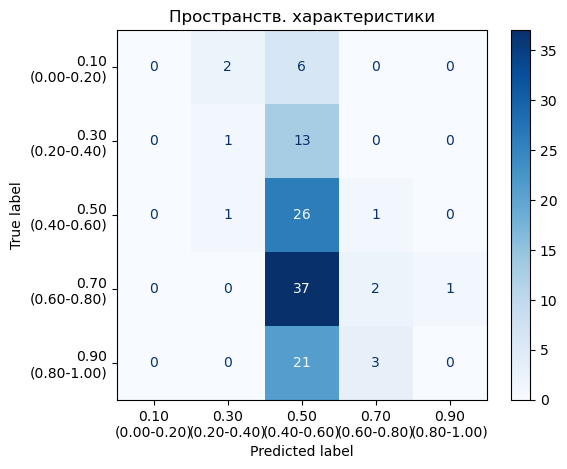

                  precision    recall  f1-score   support

0.10
(0.00-0.20)       0.00      0.00      0.00         8
0.30
(0.20-0.40)       0.25      0.07      0.11        14
0.50
(0.40-0.60)       0.25      0.93      0.40        28
0.70
(0.60-0.80)       0.33      0.05      0.09        40
0.90
(0.80-1.00)       0.00      0.00      0.00        24

        accuracy                           0.25       114
       macro avg       0.17      0.21      0.12       114
    weighted avg       0.21      0.25      0.14       114



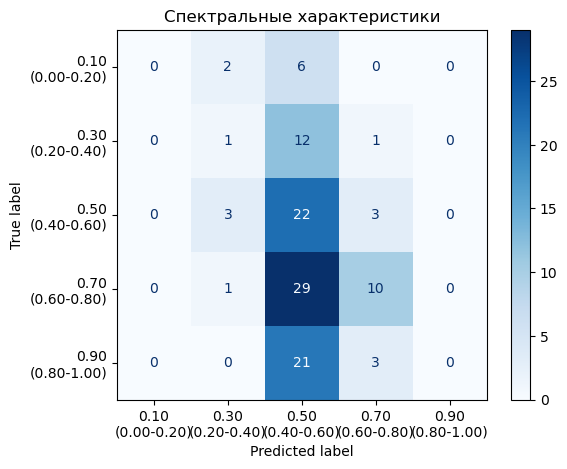

                  precision    recall  f1-score   support

0.10
(0.00-0.20)       0.00      0.00      0.00         8
0.30
(0.20-0.40)       0.14      0.07      0.10        14
0.50
(0.40-0.60)       0.24      0.79      0.37        28
0.70
(0.60-0.80)       0.59      0.25      0.35        40
0.90
(0.80-1.00)       0.00      0.00      0.00        24

        accuracy                           0.29       114
       macro avg       0.20      0.22      0.16       114
    weighted avg       0.28      0.29      0.23       114



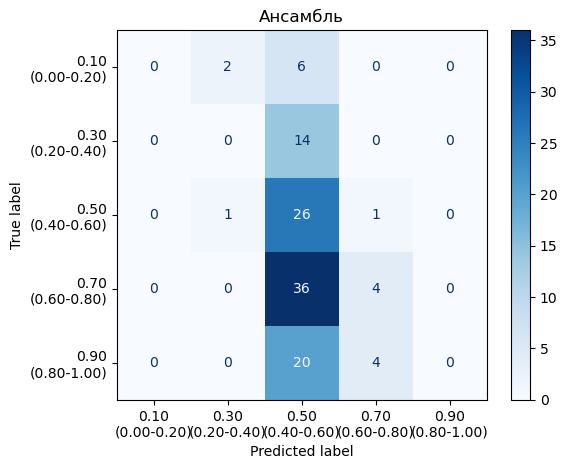

                  precision    recall  f1-score   support

0.10
(0.00-0.20)       0.00      0.00      0.00         8
0.30
(0.20-0.40)       0.00      0.00      0.00        14
0.50
(0.40-0.60)       0.25      0.93      0.40        28
0.70
(0.60-0.80)       0.44      0.10      0.16        40
0.90
(0.80-1.00)       0.00      0.00      0.00        24

        accuracy                           0.26       114
       macro avg       0.14      0.21      0.11       114
    weighted avg       0.22      0.26      0.16       114



In [41]:
confusion_report(y, p1, boundaries, 'Пространств. характеристики')
confusion_report(y, p2, boundaries, 'Спектральные характеристики')
confusion_report(y, (best_w * p1 + (1-best_w) * p2), boundaries, 'Ансамбль')

Для сравнения, "тупая" модель (предсказывает самый яастый класс):

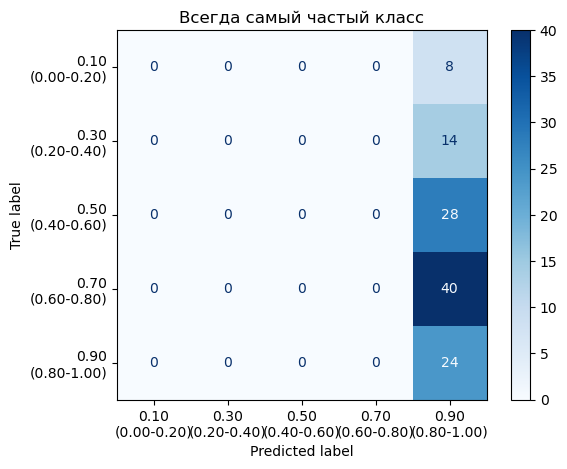

                  precision    recall  f1-score   support

0.10
(0.00-0.20)       0.00      0.00      0.00         8
0.30
(0.20-0.40)       0.00      0.00      0.00        14
0.50
(0.40-0.60)       0.00      0.00      0.00        28
0.70
(0.60-0.80)       0.00      0.00      0.00        40
0.90
(0.80-1.00)       0.21      1.00      0.35        24

        accuracy                           0.21       114
       macro avg       0.04      0.20      0.07       114
    weighted avg       0.04      0.21      0.07       114



In [42]:
edges = np.linspace(0.5 - err_base*2, 0.5 + err_base*2, 5)
y_cls = np.digitize(y, edges)

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(y_cls.reshape(-1,1), y_cls)
p3 = dummy.predict(y_cls.reshape(-1,1))

confusion_report(y, p3, boundaries, 'Всегда самый частый класс')

Полный список предсказаний:

_(в нашем случае именно это, по идее, будет выступать одной из самых важных метрик, поскольку при отклонении_ <20% (🟢) _категория всё ещё будет определяться корректно, а при отклонении_ 40+% (🔴) _ни о какой точности речи уже не идёт)_

In [43]:
errors = np.abs(y - (best_w * p1 + (1 - best_w) * p2))

idx = np.argsort(errors)
for i in idx:
    print(
        f'№ {i}\t| Реальн.: {y[i]:.2f}\t'
        + f'| Предск.: {(best_w * p1 + (1 - best_w) * p2)[i]:.10f}\t'
        + f'| Ошибка: {'🔴' if errors[i] > err_base*2 else '⭕' if errors[i] > err_base else '🟢'} {errors[i]:.10f}'
    )


print(f'\n⭕ Ошибок >{err_base * 100} %: {len(errors[errors > err_base])} / {len(errors)}')
print(f'🔥 Итог: {len(errors[errors <= err_base]) / len(errors) * 100} %')

print(f'🔴 Ошибок >{err_base*2 * 100} %: {len(errors[errors > err_base*2])} / {len(errors)}')
print(f'🔥 Итог: {len(errors[errors <= err_base*2]) / len(errors) * 100} %')

№ 89	| Реальн.: 0.50	| Предск.: 0.4934115446	| Ошибка: 🟢 0.0065884554
№ 38	| Реальн.: 0.70	| Предск.: 0.6900296289	| Ошибка: 🟢 0.0099703592
№ 45	| Реальн.: 0.50	| Предск.: 0.5210808617	| Ошибка: 🟢 0.0210808617
№ 26	| Реальн.: 0.70	| Предск.: 0.6776816404	| Ошибка: 🟢 0.0223183477
№ 31	| Реальн.: 0.50	| Предск.: 0.5262641817	| Ошибка: 🟢 0.0262641817
№ 51	| Реальн.: 0.50	| Предск.: 0.5266354814	| Ошибка: 🟢 0.0266354814
№ 63	| Реальн.: 0.50	| Предск.: 0.4722648898	| Ошибка: 🟢 0.0277351102
№ 47	| Реальн.: 0.50	| Предск.: 0.5299478492	| Ошибка: 🟢 0.0299478492
№ 41	| Реальн.: 0.50	| Предск.: 0.4696948910	| Ошибка: 🟢 0.0303051090
№ 1	| Реальн.: 0.50	| Предск.: 0.5369094241	| Ошибка: 🟢 0.0369094241
№ 40	| Реальн.: 0.50	| Предск.: 0.4626646709	| Ошибка: 🟢 0.0373353291
№ 109	| Реальн.: 0.50	| Предск.: 0.5385611278	| Ошибка: 🟢 0.0385611278
№ 30	| Реальн.: 0.50	| Предск.: 0.4576645920	| Ошибка: 🟢 0.0423354080
№ 2	| Реальн.: 0.50	| Предск.: 0.5514994887	| Ошибка: 🟢 0.0514994887
№ 34	| Реальн.: 0.50	

Похоже, выше где-то 65% точности между группами из этих данных выжать уже не получится никак...? Но точность на бОльших масштабах оценивания (+2 -- 0, 0 -- -2 и пр.) меня все равно не может не радовать!